<a href="https://colab.research.google.com/github/autumnliaves/Autoencoders_practica/blob/main/Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Importar las librerías**

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model



**2. Cargar el dataset**

In [25]:

url = '/content/Synthetic_Financial_datasets_log.csv'
df = pd.read_csv(url)


df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


<ipython-input-26-6457a597f921>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')


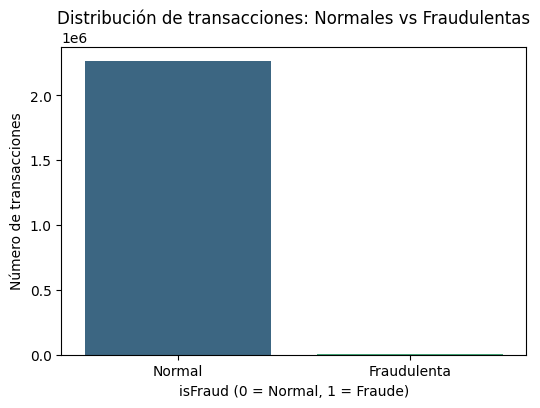

In [26]:
fraud_counts = df['isFraud'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')
plt.title('Distribución de transacciones: Normales vs Fraudulentas')
plt.xlabel('isFraud (0 = Normal, 1 = Fraude)')
plt.ylabel('Número de transacciones')
plt.xticks([0,1], ['Normal', 'Fraudulenta'])
plt.show()

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2263777 entries, 0 to 2263776
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 190.0+ MB


In [28]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,1


In [29]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,2.263777e+06,2.263777e+06,2.263777e+06,2.263777e+06,2.263777e+06,2.263777e+06,2.263776e+06,2263776.0
mean,9.631760e+01,1.613117e+05,8.522751e+05,8.737858e+05,9.992058e+05,1.114867e+06,9.382554e-04,0.0
std,6.693241e+01,2.689414e+05,2.921657e+06,2.957962e+06,2.307296e+06,2.397408e+06,3.061659e-02,0.0
min,1.000000e+00,6.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,2.300000e+01,1.323748e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,1.310000e+02,7.906747e+04,1.480900e+04,0.000000e+00,1.409840e+05,2.317005e+05,0.000000e+00,0.0
75%,1.590000e+02,2.168887e+05,1.185590e+05,1.606602e+05,9.522167e+05,1.151650e+06,0.000000e+00,0.0
max,1.870000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.228378e+07,4.265577e+07,1.000000e+00,0.0


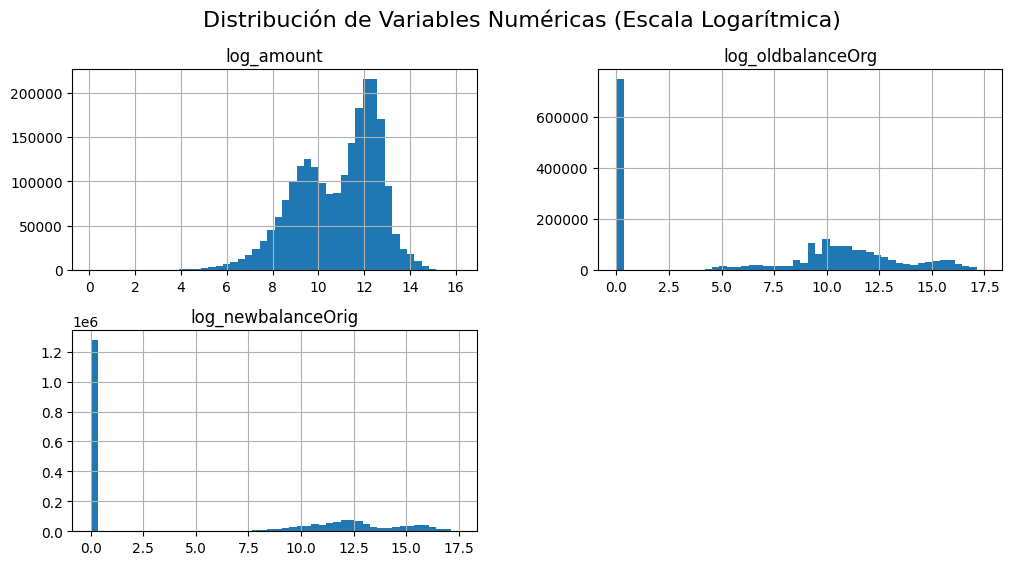

In [30]:
import numpy as np

# Agregar una pequeña constante para evitar log(0)
df['log_amount'] = np.log1p(df['amount'])
df['log_oldbalanceOrg'] = np.log1p(df['oldbalanceOrg'])
df['log_newbalanceOrig'] = np.log1p(df['newbalanceOrig'])

# Ahora graficamos los log-transformados
df[['log_amount', 'log_oldbalanceOrg', 'log_newbalanceOrig']].hist(bins=50, figsize=(12,6))
plt.suptitle('Distribución de Variables Numéricas (Escala Logarítmica)', fontsize=16)
plt.show()

**3. Normalización de datos**

In [31]:
# 1. Eliminar columnas irrelevantes
df_clean = df.drop(['nameOrig', 'nameDest'], axis=1)

# 2. Aplicar One-Hot Encoding a 'type'
df_clean = pd.get_dummies(df_clean, columns=['type'])

# 3. Transformar variables con valores extremadamente altos (log(1+x))
df_clean['amount'] = np.log1p(df_clean['amount'])
df_clean['oldbalanceOrg'] = np.log1p(df_clean['oldbalanceOrg'])
df_clean['newbalanceOrig'] = np.log1p(df_clean['newbalanceOrig'])
df_clean['oldbalanceDest'] = np.log1p(df_clean['oldbalanceDest'])
df_clean['newbalanceDest'] = np.log1p(df_clean['newbalanceDest'])

# 4. Separar características (features) y etiquetas (labels)
# No vamos a escalar las etiquetas isFraud e isFlaggedFraud
features = df_clean.drop(['isFraud', 'isFlaggedFraud'], axis=1)
labels = df_clean[['isFraud', 'isFlaggedFraud']]

# 5. Normalizar las características
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 6. Convertir las features escaladas de nuevo a DataFrame
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

# 7. Juntar features normalizadas con las etiquetas
df_scaled = pd.concat([features_scaled, labels.reset_index(drop=True)], axis=1)

# 8. Visualizar las primeras filas
df_scaled.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,log_amount,log_oldbalanceOrg,log_newbalanceOrig,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud,isFlaggedFraud
0,-1.424088,-0.915888,0.807009,1.031154,-1.163025,-1.256564,-0.915888,0.807009,1.031154,-0.53184,-0.747183,-0.081094,1.418968,-0.300591,0.0,0.0
1,-1.424088,-1.834074,0.441881,0.699029,-1.163025,-1.256564,-1.834074,0.441881,0.699029,-0.53184,-0.747183,-0.081094,1.418968,-0.300591,0.0,0.0
2,-1.424088,-3.118876,-0.393619,-0.853087,-1.163025,-1.256564,-3.118876,-0.393619,-0.853087,-0.53184,-0.747183,-0.081094,-0.704737,3.326774,1.0,0.0
3,-1.424088,-3.118876,-0.393619,-0.853087,0.321309,-1.256564,-3.118876,-0.393619,-0.853087,-0.53184,1.338361,-0.081094,-0.704737,-0.300591,1.0,0.0
4,-1.424088,-0.821797,0.559597,0.767086,-1.163025,-1.256564,-0.821797,0.559597,0.767086,-0.53184,-0.747183,-0.081094,1.418968,-0.300591,0.0,0.0


**4. Separar datos normales**

In [32]:
# Datos normales (no fraude)
df_normal = df_scaled[df_scaled['isFraud'] == 0]

# Eliminamos la columna 'isFraud' y 'isFlaggedFraud' para entrenar (solo queremos los features)
X_train = df_normal.drop(['isFraud', 'isFlaggedFraud'], axis=1)

**5. Construir modelo autoencoder**

In [33]:
input_dim = X_train.shape[1]
input_dim

14

In [34]:
# Definir dimensiones
input_dim = X_train.shape[1]
encoding_dim = 14
# Construir el autoencoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 14)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 420 (1.64 KB)

 Trainable params: 420 (1.64 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Entrenar
history = autoencoder.fit(X_train, X_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_split=0.2,
                          verbose=1)

Epoch 1/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - loss: 0.6351 - val_loss: 0.5322
Epoch 2/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5553 - val_loss: 0.5319
Epoch 3/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5537 - val_loss: 0.5318
Epoch 4/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5541 - val_loss: 0.5318
Epoch 5/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5546 - val_loss: 0.5318
Epoch 6/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5542 - val_loss: 0.5317
Epoch 7/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5539 - val_loss: 0.5317
Epoch 8/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5553 - val_loss: 0.5317
Epoch 9/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5535 - val_loss: 0.5317
Epoch 10/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5541 - val_loss: 0.5317
Epoch 11/50
7068/7068 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.5551 - val_loss: 0.5317
Epoch 12/50
7068/70

In [36]:
# Primero usamos el modelo para reconstruir X_train
X_train_pred = autoencoder.predict(X_train)

# Calculamos el error de reconstrucción
reconstruction_error = np.mean(np.power(X_train - X_train_pred, 2), axis=1)

70677/70677 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step


In [37]:
# Umbral: por ejemplo, el percentil 95 de los errores
threshold = np.percentile(reconstruction_error, 95)
print("Threshold para detección de anomalías:", threshold)

Threshold para detección de anomalías: 0.9996533849275465


In [38]:
# Dataset completo sin las etiquetas
X_all = df_scaled.drop(['isFraud', 'isFlaggedFraud'], axis=1)

# Predicción y error en todo el dataset
X_all_pred = autoencoder.predict(X_all)
all_errors = np.mean(np.power(X_all - X_all_pred, 2), axis=1)

# Detección: 1 si error > threshold, 0 si no
anomaly_predictions = (all_errors > threshold).astype(int)

# Evaluación contra las etiquetas reales
from sklearn.metrics import classification_report



70744/70744 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/_array_api.py:399: RuntimeWarning: invalid value encountered in cast
  return x.astype(dtype, copy=copy, casting=casting)


ValueError: Input y_true contains NaN.

In [39]:
# Verifica cuántos NaN hay (solo para confirmar)
print(df_scaled['isFraud'].isnull().sum())

# Elimina las filas que tienen NaN en isFraud
df_clean_eval = df_scaled[df_scaled['isFraud'].notnull()]

# También asegura que anomaly_predictions tenga la misma longitud
anomaly_predictions_clean = anomaly_predictions[df_scaled['isFraud'].notnull()]

# Ahora sí: evalúa correctamente
from sklearn.metrics import classification_report
print(classification_report(df_clean_eval['isFraud'], anomaly_predictions_clean))


1
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97   2261652
         1.0       0.00      0.10      0.00      2124

    accuracy                           0.95   2263776
   macro avg       0.50      0.53      0.49   2263776
weighted avg       1.00      0.95      0.97   2263776



In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# 1. Predecimos reconstrucción con el autoencoder
X_all = df_scaled.drop(['isFraud', 'isFlaggedFraud'], axis=1)
X_all_pred = autoencoder.predict(X_all)
all_errors = np.mean(np.power(X_all - X_all_pred, 2), axis=1)

# 2. Eliminamos cualquier fila con NaN en la etiqueta real
mask_valid = df_scaled['isFraud'].notnull()
X_all_valid = X_all[mask_valid]
y_true = df_scaled.loc[mask_valid, 'isFraud']
all_errors_valid = all_errors[mask_valid]

# 3. Thresholds a probar (puedes modificar los percentiles aquí)
percentiles = [90, 95, 97, 98, 99, 99.5]
results = []

# 4. Probar cada threshold
for p in percentiles:
    threshold = np.percentile(all_errors_valid, p)
    y_pred = (all_errors_valid > threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    results.append({
        'Percentil': p,
        'Threshold': round(threshold, 6),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4)
    })

# 5. Mostrar resultados como tabla
results_df = pd.DataFrame(results)
results_df



70744/70744 ━━━━━━━━━━━━━━━━━━━━ 77s 1ms/step


,Percentil,Threshold,Precision,Recall,F1-score
0,90.0,0.873573,0.0022,0.2321,0.0043
1,95.0,0.999857,0.0019,0.1036,0.0038
2,97.0,1.157155,0.0016,0.0504,0.0031
3,98.0,1.342034,0.0007,0.0141,0.0013
4,99.0,1.920745,0.0003,0.0033,0.0006
5,99.5,9.559981,0.0000,0.0000,0.0000
